# 01. Why Interpretability Matters in Decision Systems

Interpretability is often discussed as if it were an optional layer added after a machine-learning model has already been chosen. In decision science, that framing is too weak. A model is not deployed into a vacuum. It is embedded inside a workflow that allocates scarce resources, triggers interventions, exposes an organization to regulatory or reputational risk, and affects whether downstream actions can be justified to humans.

This first lecture sets the intellectual frame for the entire course. We will treat interpretability as part of **model design**, **decision design**, and **governance design**. The question asks whether a model predicts accurately and whether its predictions can be used responsibly under uncertainty.

To make the discussion concrete, we will work through a synthetic account-operations problem. A platform team wants to predict which business accounts need specialist review in the next month so that scarce technical support capacity can be allocated before service failures occur. We will compare a transparent logistic model to a more flexible tree ensemble, evaluate the performance tradeoff, inspect global and local structure, and show why predictive explanation is still not the same thing as causal reasoning.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain why interpretability is a decision-system requirement rather than only a model-inspection convenience.
2. Write down the relationship among a predictive score, a decision rule, and expected utility.
3. Distinguish different audiences for interpretation, including analysts, operators, auditors, and affected stakeholders.
4. Compare a transparent model and a black-box model using both predictive metrics and deployment-oriented utility.
5. Interpret logistic-regression coefficients globally and contribution-style decompositions locally.
6. Explain why a feature can be predictively important without being an intervention target.
7. Articulate a principled rule for choosing a model when performance, explanation quality, and governance all matter.

In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:0.3f}')
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 120)
np.random.seed(2026)

CATEGORICAL_LEVELS = {
    'segment': ['growth', 'mid-market', 'enterprise'],
    'region': ['North', 'South', 'West', 'International'],
}


def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1.0 / (1.0 + np.exp(-x))


def make_one_hot_encoder(categories=None):
    """Construct the one hot encoder helper used in the 01. Why Interpretability Matters in Decision Systems workflow.
    
    Parameters
    ----------
    categories : object
        The categories setting that controls the one hot encoder calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the one hot encoder calculation and reused by later cells.
    """
    encoder_kwargs = {
        'handle_unknown': 'ignore',
        'drop': 'first',
    }
    if categories is not None:
        encoder_kwargs['categories'] = categories
    try:
        return OneHotEncoder(sparse_output=False, **encoder_kwargs)
    except TypeError:
        return OneHotEncoder(sparse=False, **encoder_kwargs)


def clean_feature_name(name):
    """Clean feature name so it can be interpreted in the 01. Why Interpretability Matters in Decision Systems workflow.
    
    Parameters
    ----------
    name : object
        Readable name used to label a model, variable, scenario, or diagnostic object.
    
    Returns
    -------
    object
        Intermediate result produced by the feature name calculation and reused by later cells.
    """
    cleaned = name.replace('num__', '').replace('cat__', '')
    cleaned = cleaned.replace('segment_', 'segment = ')
    cleaned = cleaned.replace('region_', 'region = ')
    return cleaned


def rate_by_quantile(df, column, target='needs_specialist_review', q=6):
    """Carry out the rate by quantile step used in the 01. Why Interpretability Matters in Decision Systems workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    column : object
        Column or variable name used to select information from the input table.
    target : object
        Target column name or target values used by the supervised task.
    q : object
        Quantile level used by the risk, interval, or tail calculation.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    frame = df[[column, target]].copy()
    frame['bin'] = pd.qcut(frame[column], q=q, duplicates='drop')
    summary = (
        frame.groupby('bin', observed=False)
        .agg(mean_feature=(column, 'mean'), review_rate=(target, 'mean'), count=(target, 'size'))
        .reset_index(drop=True)
    )
    return summary


def policy_summary(probabilities, outcomes, thresholds):
    """Carry out the policy summary step used in the 01. Why Interpretability Matters in Decision Systems workflow.
    
    Parameters
    ----------
    probabilities : object
        Predicted probabilities used by the decision rule.
    outcomes : object
        The outcomes setting that controls the policy summary calculation in this notebook.
    thresholds : object
        Candidate decision cutoffs compared by the evaluation step.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    outcomes = np.asarray(outcomes)
    rows = []
    for threshold in thresholds:
        action = (probabilities >= threshold).astype(int)
        utility = np.select(
            [
                (action == 1) & (outcomes == 1),
                (action == 1) & (outcomes == 0),
                (action == 0) & (outcomes == 1),
            ],
            [900, -120, -1400],
            default=0,
        )
        tp = ((action == 1) & (outcomes == 1)).sum()
        fp = ((action == 1) & (outcomes == 0)).sum()
        fn = ((action == 0) & (outcomes == 1)).sum()
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        rows.append(
            {
                'threshold': threshold,
                'mean_utility': utility.mean(),
                'review_share': action.mean(),
                'precision': precision,
                'recall': recall,
            }
        )
    return pd.DataFrame(rows)


def local_logit_contributions(pipeline, row_frame):
    """Carry out the local logit contributions step used in the 01. Why Interpretability Matters in Decision Systems workflow.
    
    Parameters
    ----------
    pipeline : object
        Scikit-learn pipeline that combines preprocessing and estimation.
    row_frame : object
        Single observation or record being converted, scored, or summarized.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    prep = pipeline.named_steps['prep']
    clf = pipeline.named_steps['clf']
    transformed = np.asarray(prep.transform(row_frame))[0]
    feature_names = [clean_feature_name(name) for name in prep.get_feature_names_out()]
    contribution = transformed * clf.coef_[0]
    table = pd.DataFrame(
        {
            'feature': feature_names,
            'value': transformed,
            'logit_contribution': contribution,
        }
    )
    table = table.loc[np.abs(table['logit_contribution']) > 1e-8].copy()
    table['abs_contribution'] = table['logit_contribution'].abs()
    table = table.sort_values('abs_contribution', ascending=False)
    intercept = clf.intercept_[0]
    probability = float(pipeline.predict_proba(row_frame)[0, 1])
    return table, intercept, probability


## 1. Interpretability Is Part of the Decision Problem

A prediction system produces a score or label, but organizations do not deploy scores for their own sake. They deploy a **decision rule** that maps model output into action. A clean mathematical skeleton is

$$
s = f(x), \qquad a = \delta(s), \qquad V(f, \delta) = \mathbb{E}[u(\delta(f(X)), Y)].
$$

Here:

- $x$ is the observed information about a unit,
- $f(x)$ is the model score,
- $\delta$ is the action rule, such as a threshold or ranking policy,
- $u(a, y)$ is the utility of taking action $a$ when the realized outcome is $y$,
- $V(f, \delta)$ is the expected utility of the full decision system.

Interpretability matters because $\delta$ is often reviewed, adjusted, challenged, escalated, or overridden by humans. In a high-stakes workflow, decision quality depends both on predictive discrimination and on whether humans can understand what the system is doing well enough to trust it, debug it, and govern it.

A second useful formalization is to treat governance as a **feasibility constraint** on model choice:

$$
\hat f_{\text{deploy}} = \arg\max_{f \in \mathcal{F}_{\text{feasible}}} \hat V(f),
$$

with

$$
\mathcal{F}_{\text{feasible}} = \left\{f \in \mathcal{F} : \hat R_n(f) \leq \hat R_n(f_{\text{best}}) + \varepsilon,\; G(f)=1\right\}.
$$

The term $\hat R_n(f)$ is an empirical loss, $f_{\text{best}}$ is the best-performing candidate in pure predictive terms, $\varepsilon$ is a tolerated performance gap, and $G(f)=1$ encodes deployment requirements such as auditability, explanation quality, monotonicity, or recourse. This captures a practical principle: **the deployed model is often the best feasible model, not the most accurate unconstrained model**.

| Audience | What they need from interpretability | Typical question |
|---|---|---|
| Analyst or model builder | Debugging, stability checks, failure-mode diagnosis | Which variables are driving the model, and are those patterns stable? |
| Operations manager | Actionability and threshold logic | Why was this account escalated and what if we tighten the review threshold? |
| Auditor, risk owner, or regulator | Traceability and governance | Can the organization explain, document, and reproduce this decision process? |
| Affected user, client, or account team | Recourse and legitimacy | What would need to change for the score to move, and is that recommendation fair? |

This audience dependence is why "interpretability" cannot be reduced to a single number. A model may be understandable globally but not locally. It may support technical debugging but provide poor stakeholder communication. It may generate visually attractive plots while still failing to justify deployment in a regulated or high-consequence setting.

## 2. Synthetic Case Study: Specialist Review Allocation

Suppose a platform serves business accounts with different levels of technical complexity. A specialist operations team can proactively review only a subset of accounts each month. The decision problem is therefore a ranking and thresholding problem:

- which accounts should be escalated to specialist review,
- which accounts can remain in the standard queue,
- and whether the prediction process is interpretable enough to defend those choices.

The target will be a binary label called `needs_specialist_review`, which indicates whether the account would experience a high-severity service event next month absent proactive intervention. The features are deliberately realistic: support burden, integration complexity, training completion, payment friction, adoption, and regional context.

| Variable | Role in the decision workflow | Interpretation note |
|---|---|---|
| `open_tickets_14d` | Recent workload pressure | More unresolved tickets often signal latent service strain |
| `usage_volatility` | Product instability or rapid usage swings | High volatility can indicate operational turbulence |
| `integration_complexity` | Technical difficulty | Complex accounts are harder to support and more escalation-prone |
| `training_completion` | Customer enablement | Better training should reduce preventable issues |
| `product_adoption` | Maturity of use | More mature adoption can stabilize the account if usage is healthy |
| `payment_delay_days` | Commercial friction marker | Can be highly predictive without necessarily being a causal lever |
| `recent_incidents_90d` | Recent reliability stress | Prior incidents often forecast future incidents |
| `csat_trend` | Customer sentiment trend | Declining sentiment can foreshadow unresolved operational risk |
| `segment`, `region` | Business context | Different client types and regions experience different workflows |
| `needs_specialist_review` | Outcome to predict | The action target for specialist allocation |


In [2]:
# Section focus: 2. Synthetic Case Study: Specialist Review Allocation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def make_review_dataset(n=6000, seed=2026):
    """Construct the review dataset helper used in the 01. Why Interpretability Matters in Decision Systems workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    segment = rng.choice(['growth', 'mid-market', 'enterprise'], size=n, p=[0.48, 0.33, 0.19])
    region = rng.choice(['North', 'South', 'West', 'International'], size=n, p=[0.31, 0.24, 0.27, 0.18])

    open_tickets_14d = rng.poisson(1.8 + 0.8 * (segment == 'mid-market') + 1.6 * (segment == 'enterprise'))
    usage_volatility = np.clip(rng.gamma(shape=2.2, scale=0.45, size=n), 0.02, 4.0)
    integration_complexity = np.clip(
        rng.normal(4.7 + 0.8 * (segment == 'mid-market') + 1.4 * (segment == 'enterprise'), 1.4, n),
        1.0,
        10.0,
    )
    training_completion = np.clip(
        0.68 + 0.14 * rng.normal(size=n) - 0.06 * (segment == 'enterprise') - 0.04 * (region == 'International'),
        0.02,
        0.99,
    )
    product_adoption = np.clip(
        0.62 + 0.13 * rng.normal(size=n) - 0.07 * usage_volatility + 0.11 * training_completion,
        0.02,
        0.99,
    )
    payment_delay_days = np.clip(
        rng.gamma(shape=1.8 + 0.3 * (segment == 'growth'), scale=2.2, size=n)
        + 0.9 * (region == 'International'),
        0.0,
        30.0,
    )
    recent_incidents_90d = rng.poisson(0.7 + 0.18 * (region == 'West') + 0.25 * (segment == 'enterprise'))
    latent_fragility = rng.normal(0.0, 1.0, n) + 0.25 * (segment == 'enterprise') + 0.18 * (region == 'West')
    csat_trend = np.clip(
        rng.normal(0.12 - 0.18 * usage_volatility + 0.24 * training_completion - 0.08 * latent_fragility, 0.33, n),
        -1.5,
        1.5,
    )

    eta = (
        -3.10
        + 0.18 * open_tickets_14d
        + 0.72 * usage_volatility
        + 0.15 * integration_complexity
        + 0.06 * payment_delay_days
        + 0.45 * recent_incidents_90d
        - 2.00 * training_completion
        - 1.10 * product_adoption
        - 0.55 * csat_trend
        + 0.12 * open_tickets_14d * (integration_complexity / 10.0)
        + 0.55 * np.maximum(usage_volatility - 1.3, 0.0)
        + 0.45 * ((open_tickets_14d >= 7) & (training_completion < 0.55))
        + 0.70 * latent_fragility
        + 0.22 * (region == 'International')
    )
    review_probability = sigmoid(eta)
    needs_specialist_review = rng.binomial(1, review_probability)

    return pd.DataFrame(
        {
            'segment': segment,
            'region': region,
            'open_tickets_14d': open_tickets_14d,
            'usage_volatility': usage_volatility,
            'integration_complexity': integration_complexity,
            'training_completion': training_completion,
            'product_adoption': product_adoption,
            'payment_delay_days': payment_delay_days,
            'recent_incidents_90d': recent_incidents_90d,
            'csat_trend': csat_trend,
            'needs_specialist_review': needs_specialist_review,
        }
    )


df = make_review_dataset()

overview = pd.DataFrame(
    {
        'quantity': [
            'Accounts',
            'Base review rate',
            'Mean open tickets (14d)',
            'Mean training completion',
            'Mean integration complexity',
        ],
        'value': [
            len(df),
            df['needs_specialist_review'].mean(),
            df['open_tickets_14d'].mean(),
            df['training_completion'].mean(),
            df['integration_complexity'].mean(),
        ],
    }
)

segment_summary = (
    df.groupby('segment', observed=False)
    .agg(
        accounts=('needs_specialist_review', 'size'),
        review_rate=('needs_specialist_review', 'mean'),
        mean_open_tickets=('open_tickets_14d', 'mean'),
        mean_training_completion=('training_completion', 'mean'),
    )
    .reset_index()
)

smart_display(overview)
smart_display(segment_summary)


,quantity,value
0,Accounts,6000.000
1,Base review rate,0.146
2,Mean open tickets (14d),2.333
3,Mean training completion,0.659
4,Mean integration complexity,5.236


,segment,accounts,review_rate,mean_open_tickets,mean_training_completion
0,enterprise,1169,0.236,3.325,0.612
1,growth,2815,0.115,1.755,0.670
2,mid-market,2016,0.138,2.563,0.671


This result is an interpretation diagnostic. For Synthetic Case Study: Specialist Review Allocation, look at whether the explanation is stable, plausible, and useful for stakeholder review. When the narrative changes across samples, baselines, or neighborhoods, the analyst should mark it as tentative before using it for a decision.


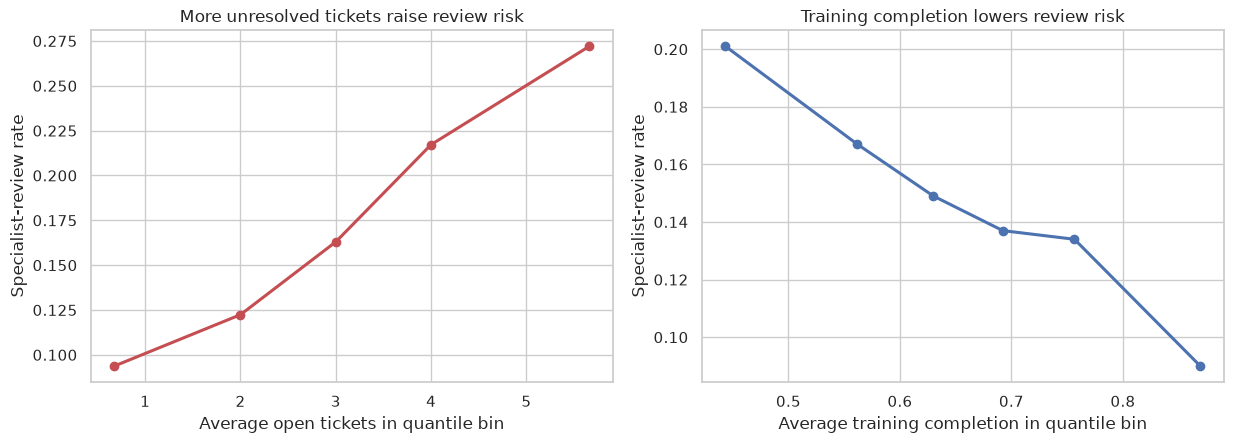

In [3]:
ticket_bins = rate_by_quantile(df, 'open_tickets_14d', q=6)
training_bins = rate_by_quantile(df, 'training_completion', q=6)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

axes[0].plot(ticket_bins['mean_feature'], ticket_bins['review_rate'], marker='o', linewidth=2.2, color='#c44e52')
axes[0].set_title('More unresolved tickets raise review risk')
axes[0].set_xlabel('Average open tickets in quantile bin')
axes[0].set_ylabel('Specialist-review rate')

axes[1].plot(training_bins['mean_feature'], training_bins['review_rate'], marker='o', linewidth=2.2, color='#4c72b0')
axes[1].set_title('Training completion lowers review risk')
axes[1].set_xlabel('Average training completion in quantile bin')
axes[1].set_ylabel('Specialist-review rate')

plt.tight_layout()
plt.show()


Even before we fit any model, the decision problem is already visible in the raw patterns.

- Accounts with heavier unresolved ticket volume are much more likely to need specialist intervention.
- Better training completion is associated with lower review risk.
- Segment summaries show that enterprise and mid-market accounts differ systematically from growth accounts in baseline workload and risk.

This is exactly where interpretability becomes operational. If a future model scores a high-risk account, stakeholders will naturally ask whether the score is being driven by a plausible combination of workload, complexity, and enablement, or by something harder to justify.

## 3. Transparent and Black-Box Models Solve Different Versions of the Same Problem

We now compare two models:

1. A **logistic regression**, which is transparent and decomposable.
2. A **random forest**, which is flexible and can capture nonlinear thresholds and interactions more naturally.

For the logistic model, the score has the form

$$
\Pr(Y=1 \mid X=x) = \sigma(\beta_0 + x^\top \beta), \qquad \sigma(z)=\frac{1}{1+e^{-z}}.
$$

This gives a direct mapping from features to log-odds contributions. In contrast, the forest prediction can be written abstractly as an average over many trees:

$$
\hat p_{\mathrm{forest}}(x) = \frac{1}{B}\sum_{b=1}^B T_b(x),
$$

where each tree $T_b$ partitions the feature space recursively. The forest may be more accurate when the true signal contains nonlinearities or threshold effects, but its internal logic is harder to communicate directly.

,model,roc_auc,average_precision,brier_score,log_loss
0,Logistic regression,0.783,0.443,0.103,0.344
1,Random forest,0.761,0.405,0.108,0.358


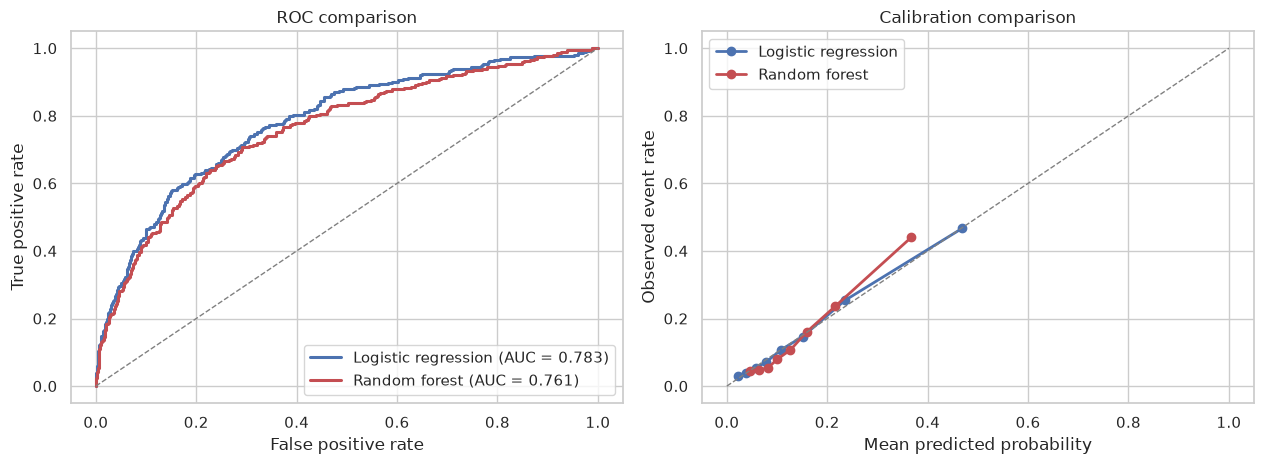

In [4]:
# Section focus: 3. Transparent and Black-Box Models Solve Different Versions of the Same Problem.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

feature_cols = [
    'open_tickets_14d',
    'usage_volatility',
    'integration_complexity',
    'training_completion',
    'product_adoption',
    'payment_delay_days',
    'recent_incidents_90d',
    'csat_trend',
    'segment',
    'region',
]
target_col = 'needs_specialist_review'

numeric_features = [
    'open_tickets_14d',
    'usage_volatility',
    'integration_complexity',
    'training_completion',
    'product_adoption',
    'payment_delay_days',
    'recent_incidents_90d',
    'csat_trend',
]
categorical_features = ['segment', 'region']

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=2026,
    stratify=y,
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        (
            'cat',
            make_one_hot_encoder(categories=[CATEGORICAL_LEVELS[name] for name in categorical_features]),
            categorical_features,
        ),
    ]
)

logit_model = Pipeline(
    steps=[
        ('prep', preprocessor),
        ('clf', LogisticRegression(max_iter=3000)),
    ]
)

forest_model = Pipeline(
    steps=[
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=400,
            max_depth=7,
            min_samples_leaf=20,
            random_state=2026,
        )),
    ]
)

logit_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)

logit_probs = logit_model.predict_proba(X_test)[:, 1]
forest_probs = forest_model.predict_proba(X_test)[:, 1]

performance = pd.DataFrame(
    {
        'model': ['Logistic regression', 'Random forest'],
        'roc_auc': [roc_auc_score(y_test, logit_probs), roc_auc_score(y_test, forest_probs)],
        'average_precision': [
            average_precision_score(y_test, logit_probs),
            average_precision_score(y_test, forest_probs),
        ],
        'brier_score': [brier_score_loss(y_test, logit_probs), brier_score_loss(y_test, forest_probs)],
        'log_loss': [log_loss(y_test, logit_probs), log_loss(y_test, forest_probs)],
    }
)

smart_display(performance)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

for probs, label, color in [
    (logit_probs, 'Logistic regression', '#4c72b0'),
    (forest_probs, 'Random forest', '#c44e52'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, label=f'{label} (AUC = {roc_auc_score(y_test, probs):0.3f})', linewidth=2.2, color=color)
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=8, strategy='quantile')
    axes[1].plot(mean_pred, frac_pos, marker='o', linewidth=2.0, label=label, color=color)

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
axes[0].set_title('ROC comparison')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].legend(frameon=True)

axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
axes[1].set_title('Calibration comparison')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Observed event rate')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


This comparison makes the central tradeoff visible.

- Even though the synthetic data contain threshold effects and interactions, the logistic model remains very strong and in this run actually outperforms the forest on the held-out set.
- That result is itself instructive: extra flexibility still has to earn deployment status.
- Calibration matters because the decision rule is threshold-based. A model with attractive complexity but weaker probability behavior can still be harder to operationalize.

This is the first main lesson of the course: **interpretability questions should begin after a predictive model is shown to be at least operationally plausible, but before the organization commits to deployment**.

## 4. What a Transparent Model Gives Us Globally

For the logistic model, interpretability is not a post-processing layer. It is built into the model equation itself. A positive coefficient increases log-odds, a negative coefficient decreases log-odds, and the odds ratio $e^{\beta_j}$ tells us how the odds change for a one-unit increase in feature $x_j$, holding the other modeled variables fixed.

For categorical variables, we will use baseline coding. In this notebook, the omitted baselines are `segment = growth` and `region = North`, so the displayed category coefficients should be read relative to those reference groups.

That phrase, "holding the other modeled variables fixed," is important. It defines a predictive conditional relationship inside the fitted model. It does **not** automatically imply a causal statement about what happens if we intervene on that feature in the real world. We will return to that distinction shortly.

,feature,coefficient,odds_ratio
3,training_completion,-1.326,0.266
4,product_adoption,-1.267,0.282
1,usage_volatility,0.957,2.604
7,csat_trend,-0.799,0.450
6,recent_incidents_90d,0.408,1.504
0,open_tickets_14d,0.284,1.328
9,segment = enterprise,0.247,1.280
12,region = International,0.214,1.238
2,integration_complexity,0.142,1.153
8,segment = mid-market,-0.089,0.915


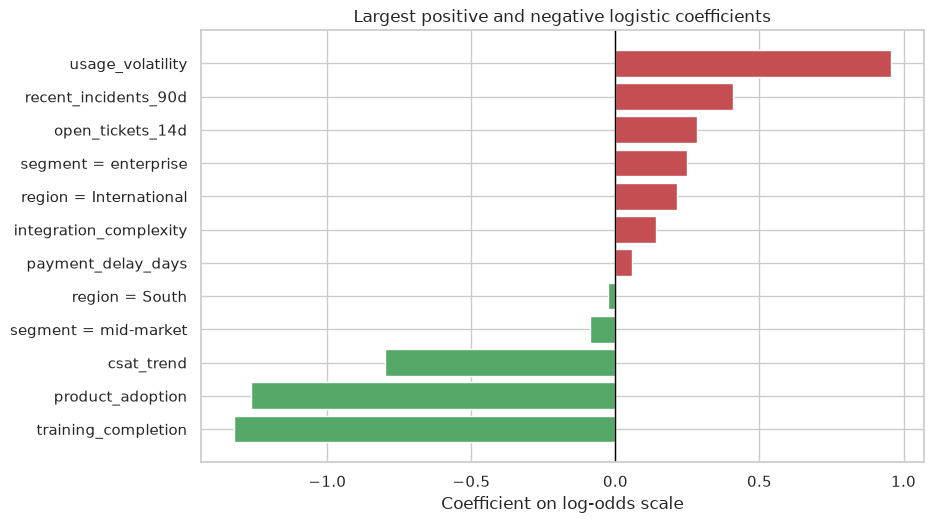

In [5]:
# Section focus: 4. What a Transparent Model Gives Us Globally.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

logit_clf = logit_model.named_steps['clf']
logit_prep = logit_model.named_steps['prep']
feature_names = [clean_feature_name(name) for name in logit_prep.get_feature_names_out()]

coef_table = pd.DataFrame(
    {
        'feature': feature_names,
        'coefficient': logit_clf.coef_[0],
    }
)
coef_table['odds_ratio'] = np.exp(coef_table['coefficient'])
coef_table['abs_coefficient'] = coef_table['coefficient'].abs()
coef_table = coef_table.sort_values('abs_coefficient', ascending=False)

smart_display(coef_table[['feature', 'coefficient', 'odds_ratio']].head(12))

plot_table = pd.concat(
    [
        coef_table.nsmallest(6, 'coefficient'),
        coef_table.nlargest(6, 'coefficient'),
    ]
).drop_duplicates('feature')
plot_table = plot_table.sort_values('coefficient')

fig, ax = plt.subplots(figsize=(9.5, 5.4))
colors = np.where(plot_table['coefficient'] > 0, '#c44e52', '#55a868')
ax.barh(plot_table['feature'], plot_table['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Largest positive and negative logistic coefficients')
ax.set_xlabel('Coefficient on log-odds scale')
plt.tight_layout()
plt.show()


A global coefficient view gives a compact answer to questions such as:

- Which features systematically push risk upward or downward?
- Are the strongest drivers substantively plausible?
- Are there category effects that would need stakeholder review before deployment?

Because the categorical coefficients are baseline-relative, a term such as `segment = enterprise` should be read as the shift in log-odds relative to `segment = growth`, after controlling for the other modeled features. A transparent model therefore supports several governance functions immediately: internal review, communication with domain experts, and rapid debugging when something looks implausible. Later notebooks will show that black-box models can also be explained, but they often require an additional explanation method whose own assumptions must then be examined.

## 5. Model Choice Depends on Utility, Not Accuracy Alone

Suppose specialist review is costly, but missing a truly risky account is much worse. Then deployment should be based on a utility function rather than a generic threshold such as 0.5. Define

$$
\hat a_t(x) = \mathbf{1}\{\hat p(x) \ge t\},
$$

where $t$ is a review threshold. We will use a stylized action utility:

- review a truly risky account: $+900$
- review a safe account unnecessarily: $-120$
- fail to review a truly risky account: $-1400$
- do nothing on a safe account: $0$

These numbers are illustrative, but the principle is real. A thresholding policy should be chosen by the value structure of the decision environment, not by habit.

,model,threshold,mean_utility,review_share,precision,recall
0,Logistic regression,0.080,40.078,0.549,0.234,0.878
1,Random forest,0.070,32.433,0.770,0.177,0.932


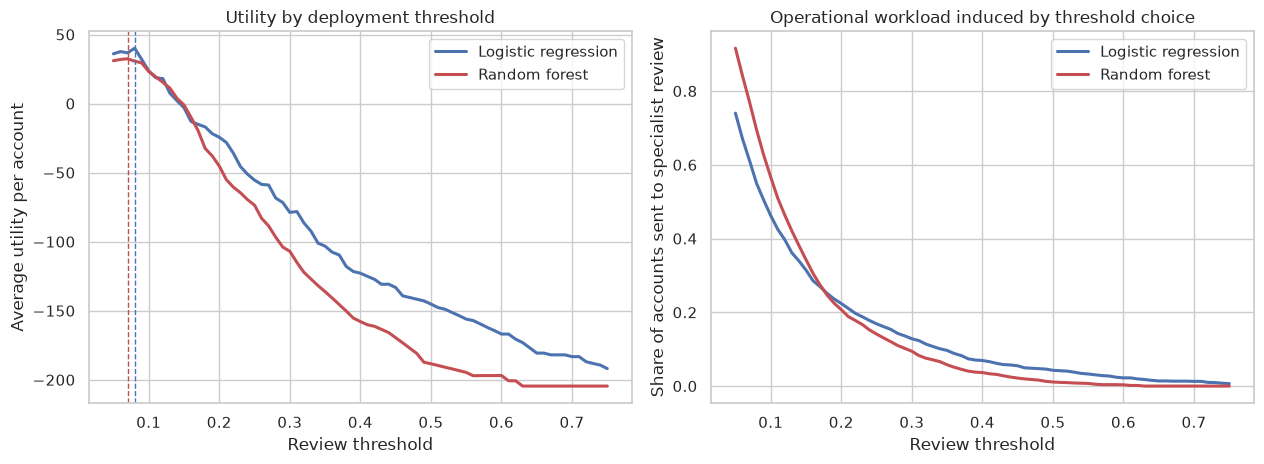

In [6]:
# Section focus: 5. Model Choice Depends on Utility, Not Accuracy Alone.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

thresholds = np.linspace(0.05, 0.75, 71)
logit_policy = policy_summary(logit_probs, y_test.to_numpy(), thresholds)
forest_policy = policy_summary(forest_probs, y_test.to_numpy(), thresholds)

logit_best = logit_policy.loc[logit_policy['mean_utility'].idxmax()].to_dict()
forest_best = forest_policy.loc[forest_policy['mean_utility'].idxmax()].to_dict()

best_policy_table = pd.DataFrame(
    [
        {'model': 'Logistic regression', **logit_best},
        {'model': 'Random forest', **forest_best},
    ]
)

smart_display(best_policy_table[['model', 'threshold', 'mean_utility', 'review_share', 'precision', 'recall']])

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

axes[0].plot(logit_policy['threshold'], logit_policy['mean_utility'], linewidth=2.2, color='#4c72b0', label='Logistic regression')
axes[0].plot(forest_policy['threshold'], forest_policy['mean_utility'], linewidth=2.2, color='#c44e52', label='Random forest')
axes[0].axvline(logit_best['threshold'], color='#4c72b0', linestyle='--', linewidth=1)
axes[0].axvline(forest_best['threshold'], color='#c44e52', linestyle='--', linewidth=1)
axes[0].set_title('Utility by deployment threshold')
axes[0].set_xlabel('Review threshold')
axes[0].set_ylabel('Average utility per account')
axes[0].legend(frameon=True)

axes[1].plot(logit_policy['threshold'], logit_policy['review_share'], linewidth=2.2, color='#4c72b0', label='Logistic regression')
axes[1].plot(forest_policy['threshold'], forest_policy['review_share'], linewidth=2.2, color='#c44e52', label='Random forest')
axes[1].set_title('Operational workload induced by threshold choice')
axes[1].set_xlabel('Review threshold')
axes[1].set_ylabel('Share of accounts sent to specialist review')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


The utility curves tell us something the metric table alone cannot.

- The best threshold is a policy choice, not a generic modeling constant.
- The low optimal threshold here reflects asymmetric error costs: missing a truly risky account is much more expensive than reviewing a safe one.
- The induced review workload matters because specialist capacity is finite, so expected utility and operational burden must be read together.

This is where the earlier feasibility idea becomes concrete. If the black-box model yields a large utility advantage, the organization may accept additional explanation machinery. If the gain is small, a transparent model may be preferable because it natively supports auditing, communication, and policy review.

## 6. Local Interpretability: Why Was *This* Account Flagged?

Global structure is not enough in practice. Review teams also need account-level reasoning. For a logistic model, the local decomposition is exact:

$$
\eta_i = \beta_0 + \sum_{j=1}^p x_{ij}\beta_j,
$$

and the predicted probability is

$$
\hat p_i = \sigma(\eta_i).
$$

The term $x_{ij}\beta_j$ is the contribution of feature $j$ to the log-odds for unit $i$. This makes it possible to explain individual cases in a way that is faithful to the fitted model rather than only approximate.

,case,open_tickets_14d,usage_volatility,integration_complexity,training_completion,product_adoption,payment_delay_days,recent_incidents_90d,csat_trend,segment,region,predicted_review_probability,observed_outcome
0,Highest predicted risk,5,3.312,5.749,0.509,0.407,2.293,3,-0.286,enterprise,North,0.932,1
1,Near deployed threshold,3,0.761,6.895,0.770,0.660,4.973,0,0.087,growth,West,0.080,0


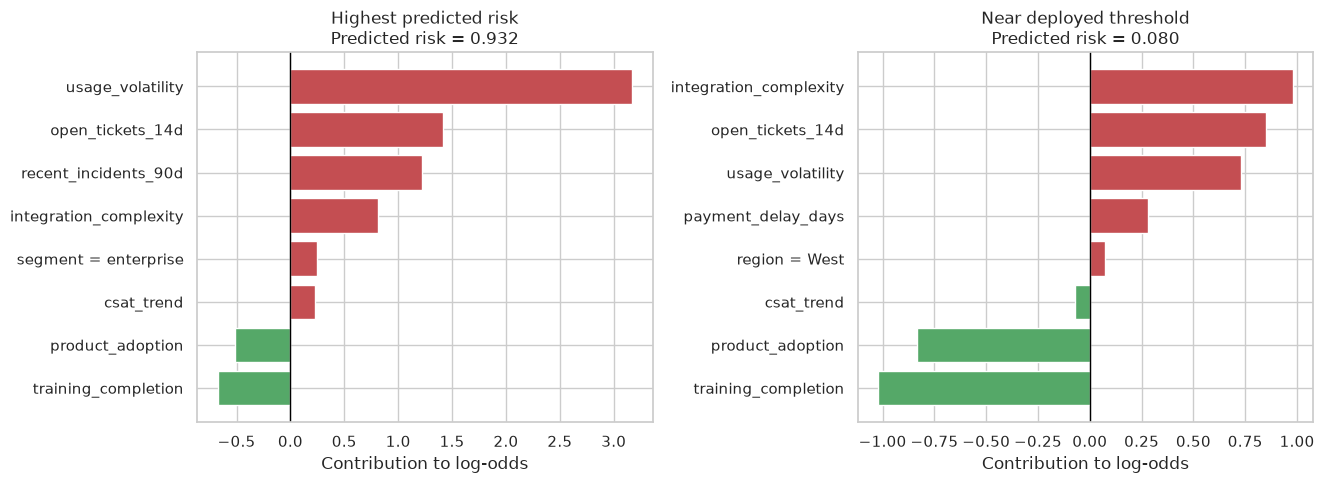

Deployed logistic-review threshold: 0.080


In [7]:
# Section focus: 6. Local Interpretability: Why Was *This* Account Flagged?.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

logit_threshold = float(logit_best['threshold'])
logit_scores = pd.Series(logit_probs, index=X_test.index)

high_risk_idx = logit_scores.idxmax()
borderline_idx = (logit_scores - logit_threshold).abs().idxmin()

case_indices = [high_risk_idx, borderline_idx]
case_labels = ['Highest predicted risk', 'Near deployed threshold']

case_profiles = X_test.loc[case_indices].copy()
case_profiles['predicted_review_probability'] = logit_scores.loc[case_indices].to_numpy()
case_profiles['observed_outcome'] = y_test.loc[case_indices].to_numpy()
case_profiles.insert(0, 'case', case_labels)
smart_display(case_profiles.reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.0))

for ax, idx, label in zip(axes, case_indices, case_labels):
    contribution_table, intercept, probability = local_logit_contributions(logit_model, X_test.loc[[idx]])
    plot_data = contribution_table.head(8).sort_values('logit_contribution')
    colors = np.where(plot_data['logit_contribution'] > 0, '#c44e52', '#55a868')
    ax.barh(plot_data['feature'], plot_data['logit_contribution'], color=colors)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'{label}\nPredicted risk = {probability:0.3f}')
    ax.set_xlabel('Contribution to log-odds')

plt.tight_layout()
plt.show()

print(f'Deployed logistic-review threshold: {logit_threshold:0.3f}')


The local view is usually where stakeholders feel the value of interpretability most directly.

- The high-risk case typically combines workload pressure, technical complexity, and weaker enablement into a coherent explanation.
- The near-threshold case is often even more important operationally because it reveals what makes a borderline account tip into review versus remain in the standard queue.
- The contribution plot is faithful to the fitted logistic model, which makes it a useful auditing and communication artifact.

Notice, however, that this decomposition explains the model, not the world. It tells us why the *score* is high, not what intervention would causally reduce future risk.

## 7. Why Predictive Explanation Is Not Causal Explanation

A recurring mistake in applied machine learning is to treat a strong predictor as if it were automatically a policy lever. Formally, predictive explanation concerns a conditional quantity such as

$$
\Pr(Y=1 \mid X_j=x, X_{-j}=x_{-j}),
$$

whereas causal intervention is about

$$
\Pr(Y=1 \mid \mathrm{do}(X_j=x)).
$$

Those are not generally equal. A variable can be predictive because it is a proxy for hidden distress, latent severity, or selection into a risky state. If so, changing the proxy may not change the underlying risk.

We can demonstrate this with a small structural simulation in which payment delay is highly informative about account distress but does not itself cause the next service crisis.

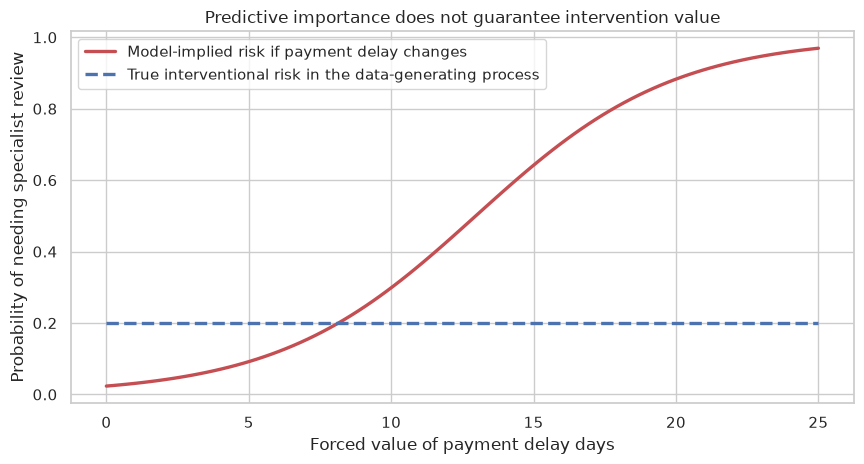

In [8]:
# Section focus: 7. Why Predictive Explanation Is Not Causal Explanation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

rng = np.random.default_rng(404)
n = 5000

latent_distress = rng.normal(0.0, 1.0, n)
training_completion_c = np.clip(0.68 + 0.12 * rng.normal(size=n), 0.05, 0.98)
open_tickets_c = rng.poisson(2.4 + 1.3 * np.maximum(latent_distress, 0.0))
payment_delay_c = np.clip(4.5 + 3.0 * latent_distress + rng.normal(0.0, 2.0, n), 0.0, 25.0)

true_eta = -2.65 + 1.40 * latent_distress + 0.16 * open_tickets_c - 1.20 * training_completion_c
y_c = rng.binomial(1, sigmoid(true_eta))

confounded_df = pd.DataFrame(
    {
        'payment_delay_days': payment_delay_c,
        'open_tickets_14d': open_tickets_c,
        'training_completion': training_completion_c,
        'needs_review': y_c,
    }
)

naive_model = LogisticRegression(max_iter=3000)
naive_model.fit(confounded_df[['payment_delay_days', 'open_tickets_14d', 'training_completion']], confounded_df['needs_review'])

delay_grid = np.linspace(0, 25, 100)
fixed_open_tickets = 4
fixed_training = 0.65
fixed_distress = 1.0

naive_curve = naive_model.predict_proba(
    pd.DataFrame(
        {
            'payment_delay_days': delay_grid,
            'open_tickets_14d': fixed_open_tickets,
            'training_completion': fixed_training,
        }
    )
)[:, 1]

true_do_probability = sigmoid(-2.65 + 1.40 * fixed_distress + 0.16 * fixed_open_tickets - 1.20 * fixed_training)
true_do_curve = np.repeat(true_do_probability, len(delay_grid))

fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.plot(delay_grid, naive_curve, linewidth=2.4, color='#c44e52', label='Model-implied risk if payment delay changes')
ax.plot(delay_grid, true_do_curve, linewidth=2.4, color='#4c72b0', linestyle='--', label='True interventional risk in the data-generating process')
ax.set_title('Predictive importance does not guarantee intervention value')
ax.set_xlabel('Forced value of payment delay days')
ax.set_ylabel('Probability of needing specialist review')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


This figure captures one of the most important warnings in the course.

The naive predictive model concludes that lower payment delay should lower risk because payment delay is strongly associated with hidden account distress. But in the simulated structural process, distress is the true driver, and mechanically setting payment delay to a smaller number does not change that distress. The model explanation is therefore **predictively faithful** but **causally misleading**.

That is why interpretability and causal reasoning must be kept distinct:

- interpretability tells us how the model uses information,
- causal reasoning tells us what would happen under intervention,
- and decision science often needs both.

## 8. Practical Takeaways

A good first deployment rule for interpretable machine learning is:

1. Build a transparent baseline early.
2. Compare it against more flexible models using metrics that matter for the decision.
3. Quantify the utility gain from additional complexity rather than assuming it matters.
4. Treat explanation quality as part of model feasibility, not as cosmetic reporting.
5. Never convert predictive explanation directly into a causal intervention claim.

This notebook does not argue that transparent models always win. It argues that a decision system should justify when opacity is worth the extra governance burden. The rest of the course will develop the tools needed to make that judgment carefully.

## References

1. Rudin, C. (2019). *Stop explaining black box machine learning models for high stakes decisions and use interpretable models instead*. Nature Machine Intelligence, 1(5), 206-215. [https://doi.org/10.1038/s42256-019-0048-x](https://doi.org/10.1038/s42256-019-0048-x)
2. Murdoch, W. J., Singh, C., Kumbier, K., Abbasi-Asl, R., & Yu, B. (2019). *Definitions, methods, and applications in interpretable machine learning*. Proceedings of the National Academy of Sciences, 116(44), 22071-22080. [https://doi.org/10.1073/pnas.1900654116](https://doi.org/10.1073/pnas.1900654116)
3. Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier*. Proceedings of NAACL-HLT, 97-101. [https://doi.org/10.18653/v1/n16-3020](https://doi.org/10.18653/v1/n16-3020)
4. Lipton, Z. C. (2018). *The mythos of model interpretability*. Communications of the ACM, 61(10), 36-43. [https://doi.org/10.1145/3233231](https://doi.org/10.1145/3233231)
5. Lipton, Z. C. (2018). *The Mythos of Model Interpretability*. Queue, 16(3), 31-57. [https://doi.org/10.1145/3236386.3241340](https://doi.org/10.1145/3236386.3241340)
